In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [4]:
# state
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state:ChatState):

    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages':response}

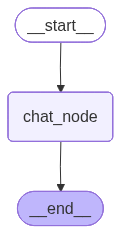

In [6]:
checkPointer = MemorySaver()

graph = StateGraph(ChatState)

# Add Node
graph.add_node('chat_node', chat_node)

# Add Edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)


# compile graph
workflow = graph.compile(checkpointer=checkPointer)
workflow

In [11]:
thread_id = 1

while True:
    user_msg = input("User:- ")
    print("\n","*"*100)
    print("\n User:- \n", user_msg, "\n \n")

    if user_msg.strip().lower() == 'exit':
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    
    print("AI:- \n")

    for message_chunk, metadata in workflow.stream( 
        {'messages': [HumanMessage(content=user_msg)]}, config=config, stream_mode='messages'
    ):
        if message_chunk.content:
            print(message_chunk.content, end=" ", flush=True)


        


 ****************************************************************************************************

 User:- 
 hi 
 

AI:- 

Hello !  😊  How  are  you  doing ? 
 ****************************************************************************************************

 User:- 
 write a essay on indian river in 500 word 
 

AI:- 

** Indian  Rivers :  Lif elines  of  the  Nation **

 India ,  a  land  of  diverse  landscapes  and  rich  natural  resources ,  is  home  to  numerous  rivers  that  have  shaped  its  history ,  culture ,  and  economy .  Rivers  in  India  are  not  just  bodies  of  water  but  lif elines  that  sustain  millions  of  people ,  support  agriculture ,  provide  drinking  water ,  and  hold  religious  and  cultural  significance .  Sp anning  from  the  snow -c apped  Himal ayas  in  the  north  to  the  pen ins ular  plateau  and  the  coastal  plains  in  the  south ,  Indian  rivers  form  an  intricate  network  that  is  vital  to  the  country ’s  surv